<a href="https://colab.research.google.com/github/Srinath77-del/network-intrusion-detection-ml/blob/main/UNSW_NB15_Week4_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving UNSW_NB15_testing-set.csv to UNSW_NB15_testing-set.csv


In [ ]:
import pandas as pd

df = pd.read_csv("UNSW_NB15_testing-set.csv")

X = df.drop(columns=["id", "attack_cat", "label"])
y = df["label"]

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("Input feature shape:", X.shape)
print("Target shape:", y.shape)
print("Target distribution:")
print(y.value_counts())

Dataset loaded successfully!
Dataset shape: (82332, 45)
Input feature shape: (82332, 42)
Target shape: (82332,)
Target distribution:
label
1    45332
0    37000
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)
print("Training target distribution:")
print(y_train.value_counts())
print("Testing target distribution:")
print(y_test.value_counts())

Training set: (65865, 42) (65865,)
Testing set: (16467, 42) (16467,)
Training target distribution:
label
1    36265
0    29600
Name: count, dtype: int64
Testing target distribution:
label
1    9067
0    7400
Name: count, dtype: int64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), numerical_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))
print("Categorical features:", categorical_features)
print("Preprocessing pipeline created successfully!")

Number of numerical features: 39
Number of categorical features: 3
Categorical features: ['proto', 'service', 'state']
Preprocessing pipeline created successfully!


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred = rf_pipeline.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))
print("First 20 predictions:", y_pred[:20])

Predictions generated successfully!
Number of predictions: 16467
First 20 predictions: [1 1 0 0 1 0 1 0 1 0 1 0 1 0 1 1 0 1 1 1]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===== RANDOM FOREST EVALUATION =====")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

===== RANDOM FOREST EVALUATION =====
Accuracy : 0.9763
Precision: 0.9844
Recall   : 0.9724
F1-Score : 0.9784


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("===== CONFUSION MATRIX =====")
print(cm)
print("True Negatives :", cm[0, 0])
print("False Positives:", cm[0, 1])
print("False Negatives:", cm[1, 0])
print("True Positives  :", cm[1, 1])

===== CONFUSION MATRIX =====
[[7260  140]
 [ 250 8817]]
True Negatives : 7260
False Positives: 140
False Negatives: 250
True Positives  : 8817


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, target_names=["Normal", "Attack"])

print("===== CLASSIFICATION REPORT =====")
print(report)

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.97      7400
      Attack       0.98      0.97      0.98      9067

    accuracy                           0.98     16467
   macro avg       0.98      0.98      0.98     16467
weighted avg       0.98      0.98      0.98     16467



In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("===== 5-FOLD STRATIFIED CROSS-VALIDATION =====")
print("Fold F1-Scores:", cv_scores)
print("Mean F1-Score:", round(cv_scores.mean(), 4))
print("Standard Deviation:", round(cv_scores.std(), 4))

===== 5-FOLD STRATIFIED CROSS-VALIDATION =====
Fold F1-Scores: [0.97832714 0.97910879 0.97892583 0.98005098 0.98029448]
Mean F1-Score: 0.9793
Standard Deviation: 0.0007


In [ ]:
y_train_pred = rf_pipeline.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)
accuracy_difference = train_accuracy - test_accuracy

print("===== OVERFITTING CHECK =====")
print("Training Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy :", round(test_accuracy, 4))
print("Accuracy Difference:", round(accuracy_difference, 4))

===== OVERFITTING CHECK =====
Training Accuracy: 1.0
Testing Accuracy : 0.9763
Accuracy Difference: 0.0236


In [ ]:
tn, fp, fn, tp = cm.ravel()

false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print("===== ERROR ANALYSIS =====")
print("False Positive Rate:", round(false_positive_rate, 4))
print("False Negative Rate:", round(false_negative_rate, 4))
print("False Positives:", fp)
print("False Negatives:", fn)

===== ERROR ANALYSIS =====
False Positive Rate: 0.0189
False Negative Rate: 0.0276
False Positives: 140
False Negatives: 250


In [ ]:
from sklearn.metrics import roc_auc_score

y_test_proba = rf_pipeline.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_test_proba)

print("===== ROC-AUC EVALUATION =====")
print("ROC-AUC Score:", round(roc_auc, 4))

===== ROC-AUC EVALUATION =====
ROC-AUC Score: 0.9971


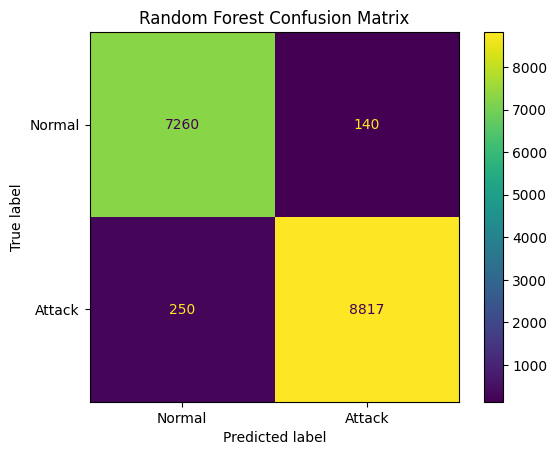

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Attack"]
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

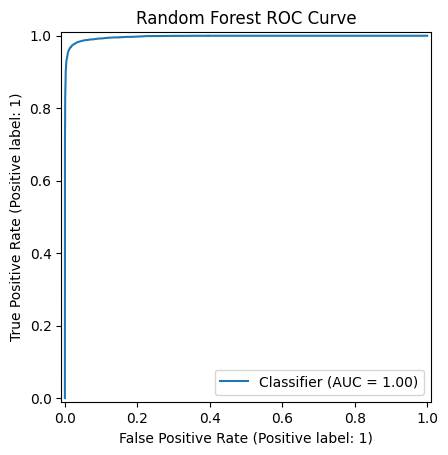

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_test_proba)
plt.title("Random Forest ROC Curve")
plt.show()

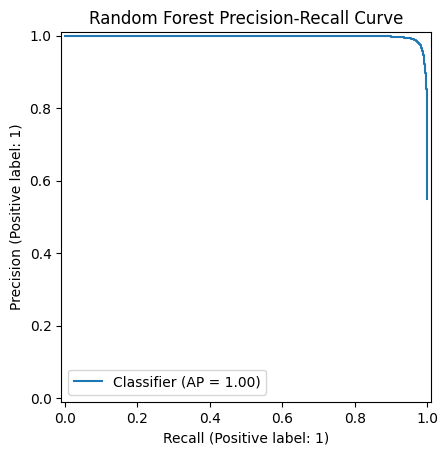

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_test_proba)
plt.title("Random Forest Precision-Recall Curve")
plt.show()

In [ ]:
week3_accuracy = 0.9769
week3_precision = 0.9840
week3_recall = 0.9739
week3_f1 = 0.9789

print("===== WEEK 3 vs WEEK 4 COMPARISON =====")
print("Metric        Week 3     Week 4")
print("Accuracy      {:.4f}     {:.4f}".format(week3_accuracy, accuracy))
print("Precision     {:.4f}     {:.4f}".format(week3_precision, precision))
print("Recall        {:.4f}     {:.4f}".format(week3_recall, recall))
print("F1-Score      {:.4f}     {:.4f}".format(week3_f1, f1))

===== WEEK 3 vs WEEK 4 COMPARISON =====
Metric        Week 3     Week 4
Accuracy      0.9769     0.9763
Precision     0.9840     0.9844
Recall        0.9739     0.9724
F1-Score      0.9789     0.9784


In [ ]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    rf_pipeline,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"],
    n_jobs=-1
)

print("===== 5-FOLD CROSS-VALIDATION RESULTS =====")
print("Mean Accuracy :", round(cv_results["test_accuracy"].mean(), 4))
print("Mean Precision:", round(cv_results["test_precision"].mean(), 4))
print("Mean Recall   :", round(cv_results["test_recall"].mean(), 4))
print("Mean F1-Score :", round(cv_results["test_f1"].mean(), 4))
print("F1 Std Dev    :", round(cv_results["test_f1"].std(), 4))

===== 5-FOLD CROSS-VALIDATION RESULTS =====
Mean Accuracy : 0.9774
Mean Precision: 0.9841
Mean Recall   : 0.9747
Mean F1-Score : 0.9793
F1 Std Dev    : 0.0007


In [ ]:
import pandas as pd

evaluation_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "CV Mean F1", "CV F1 Std"],
    "Score": [accuracy, precision, recall, f1, roc_auc, cv_results["test_f1"].mean(), cv_results["test_f1"].std()]
})

evaluation_results.to_csv("week4_evaluation_results.csv", index=False)

print("Week 4 evaluation results saved successfully!")
print(evaluation_results)

Week 4 evaluation results saved successfully!
       Metric     Score
0    Accuracy  0.976316
1   Precision  0.984370
2      Recall  0.972427
3    F1-Score  0.978362
4     ROC-AUC  0.997125
5  CV Mean F1  0.979341
6   CV F1 Std  0.000730


In [ ]:
plt.figure()
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"]).plot()
plt.title("Random Forest Confusion Matrix")
plt.savefig("week4_confusion_matrix.png", bbox_inches="tight")
plt.close()

plt.figure()
RocCurveDisplay.from_predictions(y_test, y_test_proba)
plt.title("Random Forest ROC Curve")
plt.savefig("week4_roc_curve.png", bbox_inches="tight")
plt.close()

plt.figure()
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba)
plt.title("Random Forest Precision-Recall Curve")
plt.savefig("week4_precision_recall_curve.png", bbox_inches="tight")
plt.close()

print("Week 4 evaluation figures saved successfully!")

Week 4 evaluation figures saved successfully!


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, ax = plt.subplots()
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"]).plot(ax=ax)
ax.set_title("Random Forest Confusion Matrix")
fig.savefig("week4_confusion_matrix.png", bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots()
RocCurveDisplay.from_predictions(y_test, y_test_proba, ax=ax)
ax.set_title("Random Forest ROC Curve")
fig.savefig("week4_roc_curve.png", bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots()
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba, ax=ax)
ax.set_title("Random Forest Precision-Recall Curve")
fig.savefig("week4_precision_recall_curve.png", bbox_inches="tight")
plt.close(fig)

print("Week 4 figures saved correctly!")

Week 4 figures saved correctly!


In [ ]:
final_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Mean CV Accuracy",
        "Mean CV Precision",
        "Mean CV Recall",
        "Mean CV F1-Score",
        "CV F1 Standard Deviation",
        "False Positive Rate",
        "False Negative Rate"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_f1"].std(),
        false_positive_rate,
        false_negative_rate
    ]
})

print("===== WEEK 4 FINAL EVALUATION SUMMARY =====")
print(final_summary.to_string(index=False))

final_summary.to_csv("week4_final_evaluation_summary.csv", index=False)
print("\nFinal evaluation summary saved successfully!")

===== WEEK 4 FINAL EVALUATION SUMMARY =====
                  Metric    Value
                Accuracy 0.976316
               Precision 0.984370
                  Recall 0.972427
                F1-Score 0.978362
                 ROC-AUC 0.997125
        Mean CV Accuracy 0.977360
       Mean CV Precision 0.984079
          Mean CV Recall 0.974654
        Mean CV F1-Score 0.979341
CV F1 Standard Deviation 0.000730
     False Positive Rate 0.018919
     False Negative Rate 0.027573

Final evaluation summary saved successfully!
